# Figure 3: model robustness across variant-type subgroups

**Purpose.** Summarize the distribution of subgroup AUROCs for each applicable DNA or protein model.

## Reproducibility contract

- **Run from:** the repository root.
- **Input:** `data/processed/clinvar_benchmark_updated.csv` (the full scored benchmark; not stored in GitHub).
- **Outputs:** `results/tables/figure_3_model_robustness_*.csv` and `results/figures/figure_3.svg`.
- **Randomness:** deterministic plotting jitter, seed 0.
- **Compute:** CPU; no model inference is performed.


## 1. Setup


In [1]:
from pathlib import Path
import pandas as pd

# Run this notebook from the repository root.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODEL_SCORE_DIR = DATA_DIR / "model_scores"
RESULTS_DIR = REPO_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
SCORED_BENCHMARK_PATH = DATA_DIR / "processed" / "clinvar_benchmark_updated.csv"
RANDOM_SEED = 42

def read_table(path, required_columns=()):
    """Read a local table and verify that required columns are present."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}. See README.md.")
    frame = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(
        path, low_memory=False, dtype={"#CHROM": str}
    )
    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return frame

def validate_output_files(paths):
    """Verify that every expected output was created and is not empty."""
    for value in paths:
        path = Path(value)
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Expected output was not created: {path}")
    print(f"Validated {len(paths)} output file(s).")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load and inspect input


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

DATA_PATH = SCORED_BENCHMARK_PATH
OUT_CSV = TABLE_DIR / "figure_3_model_robustness_auroc.csv"

data = pd.read_csv(DATA_PATH)
print(f"Loaded {len(data):,} variants from {DATA_PATH.relative_to(REPO_ROOT)}")


/var/folders/w5/rvfhv_qx0474bc17p1kxctd00000gn/T/ipykernel_31615/3716235887.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_PATH)


Loaded 242,132 variants from data/processed/clinvar_benchmark_updated.csv


## 3. Define model applicability


In [3]:
# Models, subgroups, and conventions are shared with VEP_AUROC_figure.ipynb.

tools = [
    "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", #"Rule_based",
    "GPN_MSA", "PhyloGPN", "gpnstar_v_llr", "DNABERT2",
    "ntv3_pre_position_llr", "ntv3_post_log2fc_max",
    "ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI_3D", "vesm_score",
]

NO_FLIP = {
    "PhyloP", "DNABERT2",
    "AlphaMissense", "PrimateAI_3D", "AlphaGenome_quantile", "Rule_based",
    "ntv3_post_log2fc_max",
}

subgroups = [
    "group: missense",
    "group: missense + 3'UTR",
    "group: missense + intron (non-splice)",
    "group: stop gain",
    "group: start loss",
    "group: noncoding",
    "group: stop loss",
    "group: synonymous",
    "group: 5'UTR",
    "group: 3'UTR",
    "group: 3'UTR + RNA gene",
    "group: splice",
    "group: intron (non-splice)",
    "group: RNA gene",
]
TOOLS_PER_SUBGROUP = {}
for i, sg in enumerate(subgroups):
    if i in (0, 1, 2, 3):
        TOOLS_PER_SUBGROUP[sg] = tools[:]
    elif i == 4:
        TOOLS_PER_SUBGROUP[sg] = tools[:13] + ["vesm_score"]
    else:
        TOOLS_PER_SUBGROUP[sg] = tools[:10]

rename_dict = {
    "Evo2_7B":               "Evo2 7B",
    "Evo2_40B":              "Evo2 40B",
    "DNABERT2":              "DNABERT2",
    "PhyloP":                "PhyloP",
    "AlphaGenome_quantile":  "AlphaGenome",
    "GPN_MSA":               "GPN-MSA",
    "PhyloGPN":              "PhyloGPN",
    "gpnstar_v_llr":         "GPN-Star",
    "ntv3_pre_position_llr": "NTv3-pre LLR",
    "ntv3_post_log2fc_max":  "NTv3-post log2FC",
    "ESM1b":                 "ESM1b",
    "ESM1v":                 "ESM1v",
    "ESM2":                  "ESM2",
    "PrimateAI_3D":          "PrimateAI-3D",
    "AlphaMissense":         "AlphaMissense",
    "vesm_score":            "VESM++",
    "Rule_based":            "Rule-based",
}
palette = {
    "Evo2 7B":           "#e56b6f",
    "Evo2 40B":          "#c93735",
    "DNABERT2":          "#1b78b2",
    "NTv3-pre LLR":      "#6baed6",
    "NTv3-pre PLLR":     "#4292c6",
    "NTv3-post LLR":     "#2171b5",
    "NTv3-post PLLR":    "#084594",
    "NTv3-post log2FC":  "#54278f",
    "GPN-Star":          "#20b2aa",
    "PhyloP":            "#808080",
    "GPN-MSA":           "#859ed7",
    "PhyloGPN":          "#f47f1e",
    "AlphaGenome":       "#a2d94d",
    "ESM1b":             "#2da248",
    "ESM1v":             "#8f69c5",
    "ESM2":              "#22bdd2",
    "VESM++":            "#e377c2",
    "PrimateAI-3D":      "#d26101",
    "AlphaMissense":     "#333a8c",
    "Rule-based":        "#b0b0b0",
}
display_map = {
    "group: noncoding":                      "Noncoding",
    "group: intron (non-splice)":            "Intron (Non-splice)",
    "group: splice":                         "Splice",
    "group: 5'UTR":                          "5' UTR",
    "group: 3'UTR":                          "3' UTR",
    "group: 3'UTR + RNA gene":               "3' UTR + RNA gene",
    "group: RNA gene":                       "RNA gene",
    "group: synonymous":                     "Synonymous",
    "group: start loss":                     "Start loss",
    "group: stop loss":                      "Stop loss",
    "group: missense":                       "Missense",
    "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
    "group: missense + 3'UTR":               "Missense & 3'UTR",
    "group: stop gain":                      "Stop gain",
}

# Group each model by modality so we can plot DNA and protein models in
# separate panels. Protein models are applicable only to coding-derived
# subgroups (missense, stop-gain, start-loss and combinations); mixing them
# with DNA models on one axis would conflate breadth of applicability with
# robustness.
DNA_MODELS = [
    "PhyloP", "AlphaGenome", "Evo2 7B", "Evo2 40B", "GPN-MSA",  #"Rule-based",
    "PhyloGPN", "GPN-Star", "NTv3-pre LLR", "NTv3-post log2FC", "DNABERT2",
]
PROTEIN_MODELS = ["ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI-3D", "VESM++"]


## 4. Compute metrics and render the figure


In [4]:
# Recompute per-subgroup AUROC so this notebook is self-contained.
# This reproduces the per-subgroup logic of VEP_AUROC_figure.ipynb exactly:
# same tools-per-subgroup mapping, same sign-flipping rules, same pairwise
# intersection of non-missing scores, and no imputation for inapplicable
# (model, subgroup) combinations.

MIN_PER_CLASS = 5  # minimum positives and negatives to compute AUROC

rows = []
for sg, sg_tools in tqdm(list(TOOLS_PER_SUBGROUP.items()), desc="Subgroups"):
    sg_df = data[data[sg] == 1]
    sg_df = sg_df[sg_df[sg_tools].notna().all(axis=1)]
    y = sg_df["ClinVar_label"].astype(int).values
    n = len(sg_df); npos = int(y.sum()); nneg = n - npos
    prev = float(npos / n) if n else np.nan
    for tool in sg_tools:
        if npos < MIN_PER_CLASS or nneg < MIN_PER_CLASS:
            auc = np.nan
        else:
            scores = sg_df[tool].values.astype(float)
            if tool not in NO_FLIP:
                scores = -scores
            auc = float(roc_auc_score(y, scores))
        rows.append({
            "subgroup_raw": sg,
            "subgroup_display": display_map.get(sg, sg),
            "model": rename_dict[tool],
            "AUROC": auc,
            "N": n, "N_pos": npos, "N_neg": nneg, "prevalence": prev,
        })

auroc_long = pd.DataFrame(rows)
auroc_long.to_csv(OUT_CSV, index=False)
print(f"Wrote {OUT_CSV.relative_to(REPO_ROOT)}: {len(auroc_long):,} rows")
auroc_long#.head()


Subgroups:   0%|          | 0/14 [00:00<?, ?it/s]

Subgroups:   7%|▋         | 1/14 [00:00<00:02,  5.91it/s]

Subgroups:  29%|██▊       | 4/14 [00:00<00:00, 14.46it/s]

Subgroups:  43%|████▎     | 6/14 [00:00<00:00,  9.98it/s]

Subgroups:  57%|█████▋    | 8/14 [00:00<00:00, 12.29it/s]

Subgroups:  93%|█████████▎| 13/14 [00:00<00:00, 15.25it/s]

Subgroups: 100%|██████████| 14/14 [00:00<00:00, 14.41it/s]

Wrote results/tables/figure_3_model_robustness_auroc.csv: 168 rows


,subgroup_raw,subgroup_display,model,AUROC,N,N_pos,N_neg,prevalence
0,group: missense,Missense,PhyloP,0.869385,37076,13705,23371,0.369646
1,group: missense,Missense,Evo2 7B,0.835707,37076,13705,23371,0.369646
2,group: missense,Missense,Evo2 40B,0.845441,37076,13705,23371,0.369646
3,group: missense,Missense,AlphaGenome,0.550094,37076,13705,23371,0.369646
4,group: missense,Missense,GPN-MSA,0.912821,37076,13705,23371,0.369646
...,...,...,...,...,...,...,...,...
163,group: RNA gene,RNA gene,PhyloGPN,0.804233,75,12,63,0.160000
164,group: RNA gene,RNA gene,GPN-Star,0.943122,75,12,63,0.160000
165,group: RNA gene,RNA gene,DNABERT2,0.472222,75,12,63,0.160000
166,group: RNA gene,RNA gene,NTv3-pre LLR,0.617725,75,12,63,0.160000


In [5]:
# Per-model robustness summary statistics.

summary = (
    auroc_long.dropna(subset=["AUROC"])
    .groupby("model")["AUROC"]
    .agg(
        n_subgroups="count",
        median="median",
        mean="mean",
        minimum="min",
        maximum="max",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
    .reset_index()
)
summary["range"] = summary["maximum"] - summary["minimum"]
summary["iqr"] = summary["q75"] - summary["q25"]
summary = summary.sort_values("median", ascending=False).reset_index(drop=True)
summary.to_csv(TABLE_DIR / "figure_3_model_robustness_summary.csv", index=False)
summary


,model,n_subgroups,median,mean,minimum,maximum,q25,q75,range,iqr
0,AlphaMissense,4,0.944955,0.921913,0.831734,0.966006,0.912308,0.954560,0.134273,0.042251
1,PrimateAI-3D,4,0.942723,0.909173,0.799135,0.952111,0.906368,0.945528,0.152976,0.039159
2,VESM++,5,0.913690,0.833496,0.648304,0.952802,0.713518,0.939167,0.304498,0.225649
3,GPN-Star,13,0.895692,0.880655,0.761833,0.987701,0.817791,0.931237,0.225868,0.113446
4,ESM1b,5,0.884226,0.845965,0.682468,0.952500,0.779030,0.931601,0.270032,0.152570
5,GPN-MSA,13,0.881472,0.868736,0.760452,0.985011,0.777651,0.928711,0.224559,0.151060
6,PhyloP,13,0.847309,0.822911,0.667857,0.980912,0.739902,0.869385,0.313055,0.129483
7,Evo2 40B,13,0.845441,0.814199,0.625894,0.985615,0.761111,0.877928,0.359721,0.116816
8,Evo2 7B,13,0.835707,0.810325,0.640212,0.978880,0.735714,0.875893,0.338668,0.140179
9,ESM1v,5,0.826339,0.781144,0.632323,0.901771,0.645286,0.900000,0.269448,0.254714


/var/folders/w5/rvfhv_qx0474bc17p1kxctd00000gn/T/ipykernel_31615/2536247199.py:62: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/w5/rvfhv_qx0474bc17p1kxctd00000gn/T/ipykernel_31615/2536247199.py:62: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/w5/rvfhv_qx0474bc17p1kxctd00000gn/T/ipykernel_31615/2536247199.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


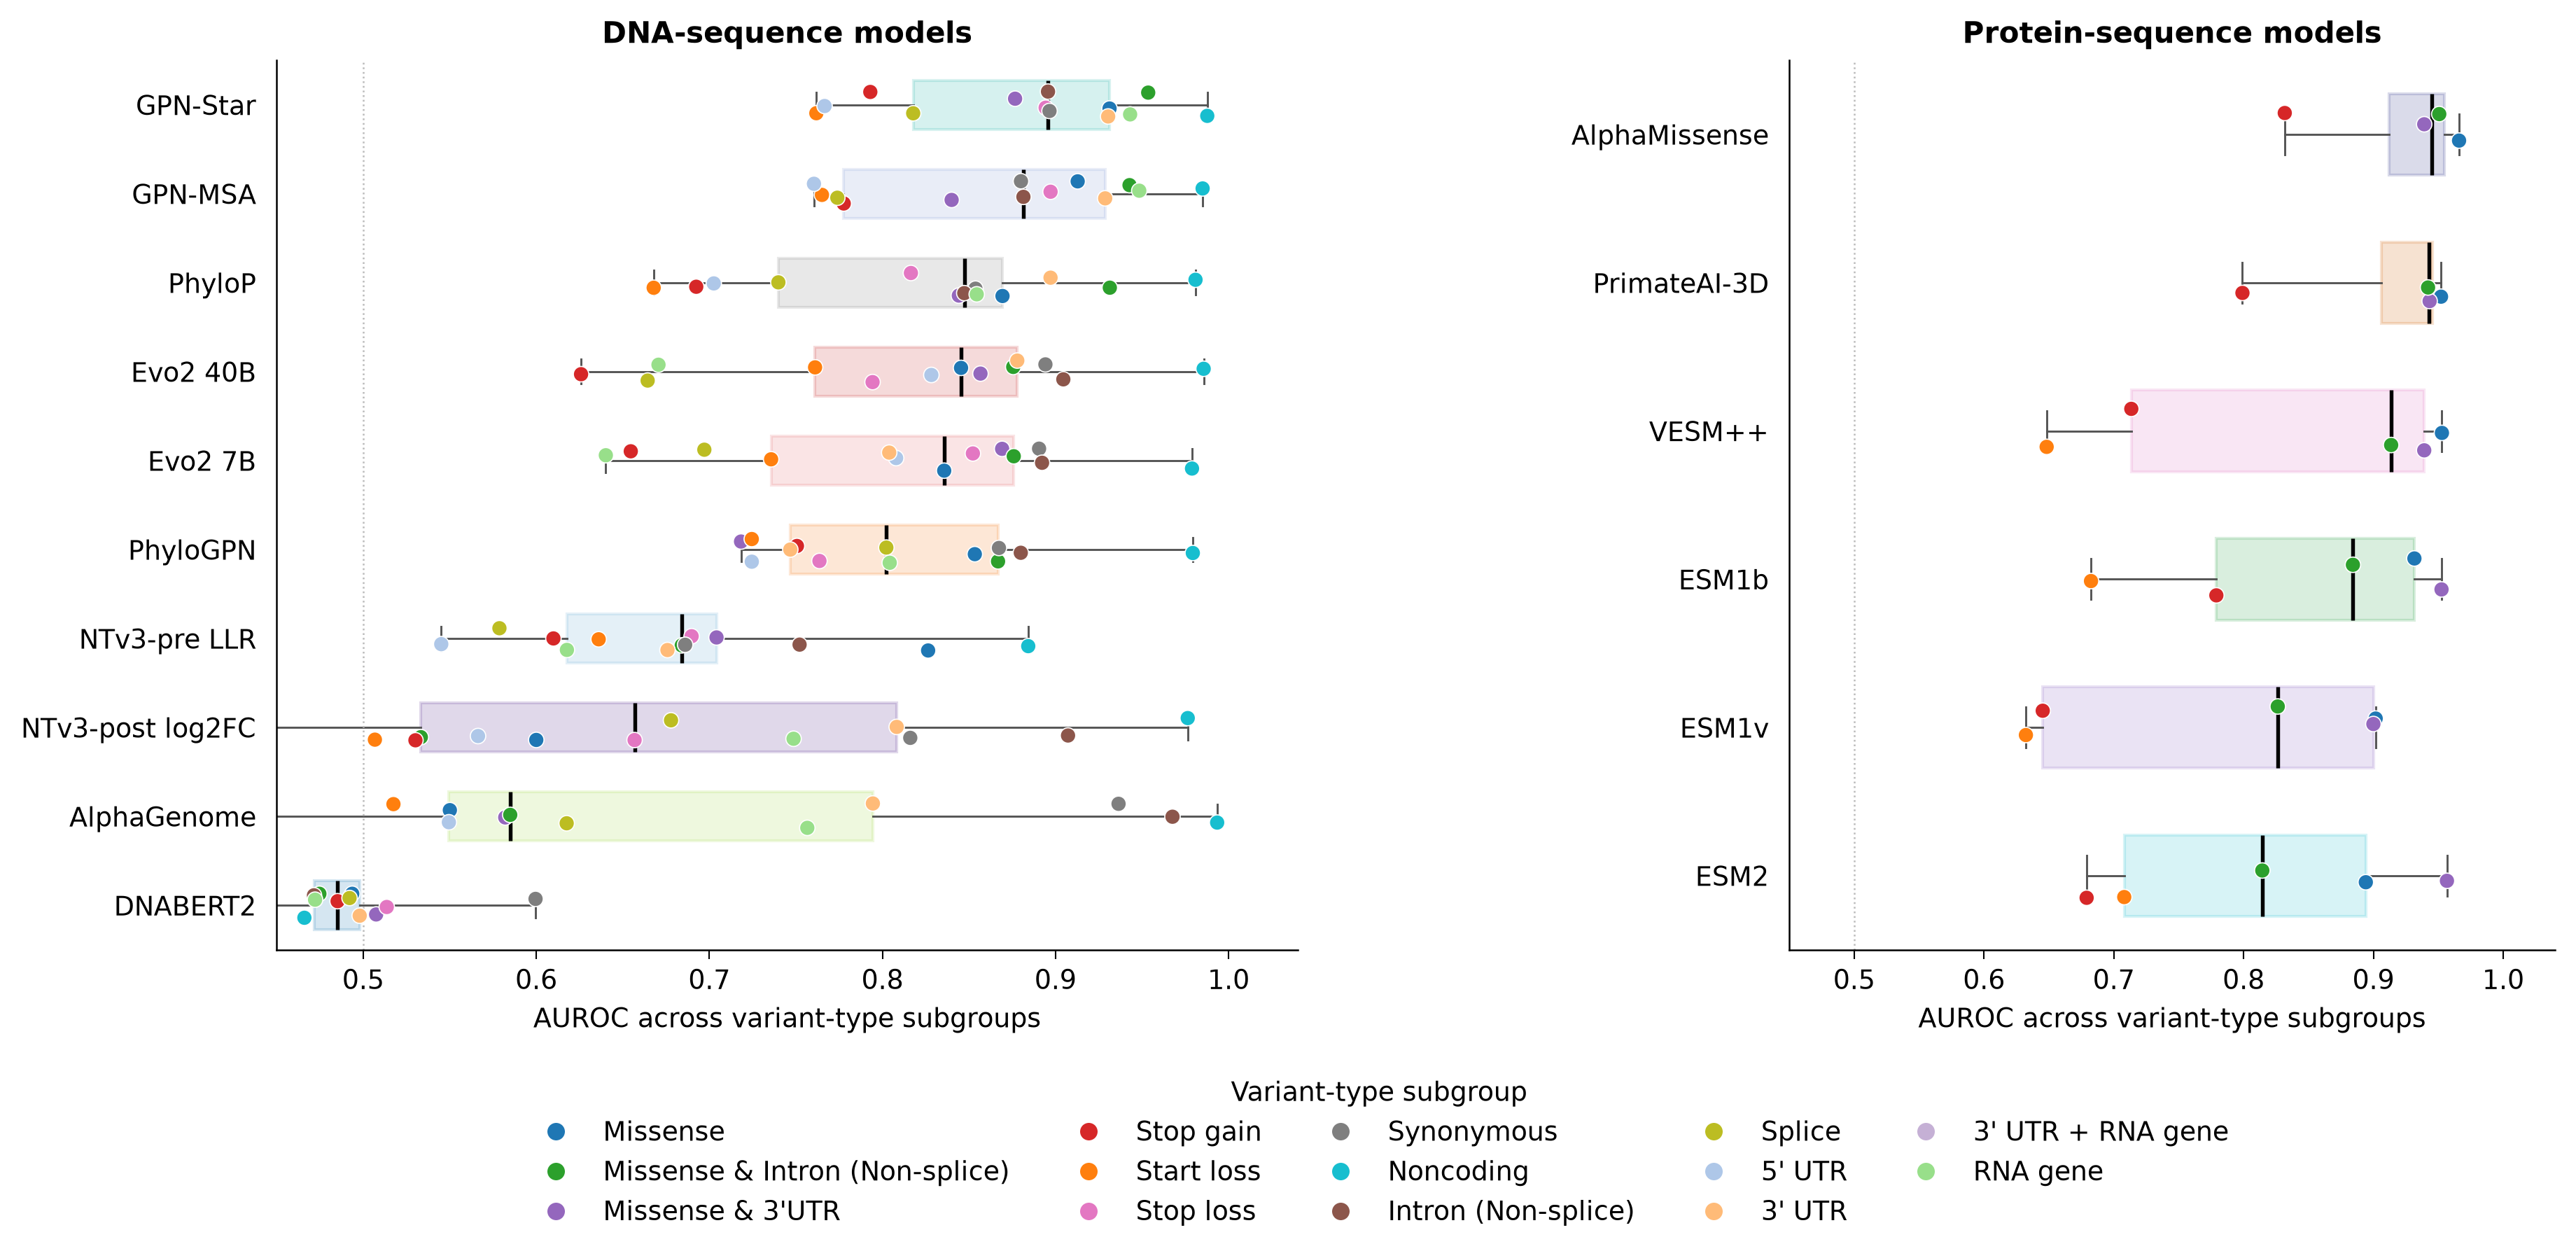

In [6]:
# Robustness summary figure: DNA models (left) and protein models (right).
# Box color is per model (same palette as Figure 1).
# Dot color is per subgroup, so for each model you can see which variant
# types pull its AUROC up or down.

FONT_SIZE = 9
FONT_NAME = "DejaVu Sans"

# Subgroup palette (dot color).
subgroup_palette = {
    # coding-derived
    "Missense":                       "#1f77b4",
    "Missense & Intron (Non-splice)": "#2ca02c",
    "Missense & 3'UTR":               "#9467bd",
    "Stop gain":                      "#d62728",
    "Start loss":                     "#ff7f0e",
    "Stop loss":                      "#e377c2",
    "Synonymous":                     "#7f7f7f",
    # non-coding
    "Noncoding":                      "#17becf",
    "Intron (Non-splice)":            "#8c564b",
    "Splice":                         "#bcbd22",
    "5' UTR":                         "#aec7e8",
    "3' UTR":                         "#ffbb78",
    "3' UTR + RNA gene":              "#c5b0d5",
    "RNA gene":                       "#98df8a",
}
subgroup_legend_order = [
    "Missense", "Missense & Intron (Non-splice)", "Missense & 3'UTR",
    "Stop gain", "Start loss", "Stop loss", "Synonymous",
    "Noncoding", "Intron (Non-splice)", "Splice",
    "5' UTR", "3' UTR", "3' UTR + RNA gene", "RNA gene",
]


def panel_stats(models):
    out = []
    for m in models:
        vals = auroc_long.loc[
            (auroc_long["model"] == m) & auroc_long["AUROC"].notna(),
            ["subgroup_display", "AUROC"]
        ]
        out.append({
            "model": m,
            "vals": vals["AUROC"].values,
            "subgroups": vals["subgroup_display"].values,
            "median": float(vals["AUROC"].median()) if len(vals) else np.nan,
        })
    out = sorted(out, key=lambda d: -d["median"])
    return out

dna_stats  = panel_stats(DNA_MODELS)
prot_stats = panel_stats(PROTEIN_MODELS)


def draw_panel(ax, stats, title):
    labels    = [s["model"] for s in stats]
    positions = np.arange(len(labels))

    # Box: median + IQR + whiskers = full range, colored per model
    box_data = [s["vals"] for s in stats]
    bp = ax.boxplot(
        box_data, positions=positions, widths=0.55, vert=False,
        patch_artist=True, whis=(0, 100), showfliers=False, zorder=1,
    )
    for i, patch in enumerate(bp["boxes"]):
        c = palette.get(labels[i], "#cccccc")
        patch.set_facecolor(c)
        patch.set_alpha(0.18)
        patch.set_edgecolor(c)
        patch.set_linewidth(1.0)
    for element in ("whiskers", "caps"):
        for line in bp[element]:
            line.set_color("#555555")
            line.set_linewidth(0.7)
    for line in bp["medians"]:
        line.set_color("black")
        line.set_linewidth(1.3)

    # Strip plot: one dot per subgroup AUROC, colored by subgroup
    rng = np.random.default_rng(0)
    for i, s in enumerate(stats):
        n      = len(s["vals"])
        ys     = positions[i] + (rng.random(n) - 0.5) * 0.30
        xs     = s["vals"]
        colors = [subgroup_palette.get(sg, "#444444") for sg in s["subgroups"]]
        ax.scatter(xs, ys, s=28, c=colors, edgecolor="white", linewidth=0.4, zorder=3)

    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=FONT_SIZE, fontname=FONT_NAME)

    ax.set_xlim(0.45, 1.04)
    ax.axvline(0.5, color="#bbbbbb", lw=0.6, ls=":")
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.set_xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_xticklabels([f"{t:.1f}" for t in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]],
                       fontsize=FONT_SIZE, fontname=FONT_NAME)
    ax.set_xlabel("AUROC across variant-type subgroups",
                  fontsize=FONT_SIZE, fontname=FONT_NAME)
    ax.set_title(title, fontsize=FONT_SIZE + 1, fontname=FONT_NAME, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.spines["left"].set_linewidth(0.6)
    ax.tick_params(axis="x", width=0.5, length=3.0)
    ax.tick_params(axis="y", width=0.0)


fig, axes = plt.subplots(
    1, 2, figsize=(14, 5.5), dpi=300,
    gridspec_kw={"width_ratios": [1.0, 0.75], "wspace": 0.55},
)
draw_panel(axes[0], dna_stats, "DNA-sequence models")
draw_panel(axes[1], prot_stats, "Protein-sequence models")

# Shared subgroup-color legend below both panels
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=subgroup_palette[sg], markeredgecolor="white",
           markersize=7, label=sg)
    for sg in subgroup_legend_order if sg in subgroup_palette
]
fig.legend(
    handles=legend_handles, loc="lower center",
    bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False,
    fontsize=FONT_SIZE, title="Variant-type subgroup",
    title_fontsize=FONT_SIZE,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_3.svg", format="svg", bbox_inches="tight")
plt.show()


In [7]:
# Quantitative verification of the robustness claim.
# Within each modality panel, identify the model with the highest minimum AUROC
# (worst-case performance) and with the highest median. The paper's claim is
# strongest when these coincide.

def rank_by(stats, key):
    return sorted(stats, key=lambda d: -{
        "median": d["median"],
        "min": float(np.min(d["vals"])) if len(d["vals"]) else -np.inf,
    }[key])

print("DNA models: ranked by median AUROC")
for s in rank_by(dna_stats, "median"):
    vmin = np.min(s["vals"]); vmed = s["median"]; vmax = np.max(s["vals"])
    print(f"  {s['model']:22s}  median={vmed:.3f}  min={vmin:.3f}  max={vmax:.3f}  n={len(s['vals'])}")

print()
print("DNA models: ranked by worst-case (min AUROC across applicable subgroups)")
for s in rank_by(dna_stats, "min"):
    vmin = np.min(s["vals"]); vmed = s["median"]
    print(f"  {s['model']:22s}  min={vmin:.3f}  median={vmed:.3f}  n={len(s['vals'])}")

print()
print("Protein models: ranked by median AUROC")
for s in rank_by(prot_stats, "median"):
    vmin = np.min(s["vals"]); vmed = s["median"]; vmax = np.max(s["vals"])
    print(f"  {s['model']:22s}  median={vmed:.3f}  min={vmin:.3f}  max={vmax:.3f}  n={len(s['vals'])}")

print()
print("Protein models: ranked by worst-case (min AUROC across applicable subgroups)")
for s in rank_by(prot_stats, "min"):
    vmin = np.min(s["vals"]); vmed = s["median"]
    print(f"  {s['model']:22s}  min={vmin:.3f}  median={vmed:.3f}  n={len(s['vals'])}")


DNA models: ranked by median AUROC
  GPN-Star                median=0.896  min=0.762  max=0.988  n=13
  GPN-MSA                 median=0.881  min=0.760  max=0.985  n=13
  PhyloP                  median=0.847  min=0.668  max=0.981  n=13
  Evo2 40B                median=0.845  min=0.626  max=0.986  n=13
  Evo2 7B                 median=0.836  min=0.640  max=0.979  n=13
  PhyloGPN                median=0.802  min=0.718  max=0.979  n=13
  NTv3-pre LLR            median=0.684  min=0.545  max=0.884  n=13
  NTv3-post log2FC        median=0.657  min=0.410  max=0.976  n=13
  AlphaGenome             median=0.585  min=0.314  max=0.993  n=13
  DNABERT2                median=0.485  min=0.394  max=0.600  n=13

DNA models: ranked by worst-case (min AUROC across applicable subgroups)
  GPN-Star                min=0.762  median=0.896  n=13
  GPN-MSA                 min=0.760  median=0.881  n=13
  PhyloGPN                min=0.718  median=0.802  n=13
  PhyloP                  min=0.668  median=0.847  n=

## Notes on the figure

- **What is plotted.** Each dot is one AUROC value for the given model on
  one variant-type subgroup (the same subgroups used in Figure 1). The
  box marks median and IQR; whiskers span the full applicable range.

- **DNA vs protein models in separate panels.** Protein models were
  evaluated only on coding-derived variants (missense, stop-gain,
  start-loss, and combinations), while DNA models and the PhyloP
  baseline were evaluated on all 14 variant-type subgroups. Plotting
  both families on a shared axis would conflate robustness with
  applicability: a protein model's narrow AUROC distribution is not
  directly comparable to a DNA model's distribution because the two
  distributions describe different sets of variant classes. We
  therefore separate them, following the reviewer's intent to
  visualise within-family robustness.

- **What the figure does, and does not, do.** It supports the
  descriptive claim in the Discussion that GPN-MSA and AlphaMissense
  have the most robust performance within their modality. It does not
  by itself prove a best-model conclusion; pairwise statistical
  comparisons at the subgroup level remain the domain of Figure 1.

- **Limitations.** Subgroups with small sample size (RNA gene,
  Missense & 3′UTR, 3′UTR + RNA gene) contribute a single AUROC
  value per model with substantial variance; this is visible as
  outlier dots in the distributions but is not treated differently in
  the summary statistics. These per-subgroup confidence intervals are
  reported in the main Figure 1 panels and should be used for
  inference-level claims.


## 5. Validate outputs


In [8]:

validate_output_files([
    TABLE_DIR / "figure_3_model_robustness_auroc.csv",
    TABLE_DIR / "figure_3_model_robustness_summary.csv",
    FIGURE_DIR / "figure_3.svg",
])


Validated 3 output file(s).
